In [ ]:
# !pip install pystac-client


#!pip install pystac_client

In [10]:
from pystac_client import Client
import json
import pystac
import pandas as pd
import geopandas as gpd
from pystac import MediaType
import rasterio
import requests
from io import BytesIO

In [11]:
url = "http://localhost:8080/"
catalog = Client.open(url)

In [12]:
# Bounding box
bbox = [85.85, 24.38, 86.25, 24.75] ##tisri
#bbox=[74.05, 11.59, 78.58, 18.45] ##karnataka


search = catalog.search(
    bbox=bbox,
    #datetime="2022-01-01/2022-12-31",
    #query={"keywords": {"eq": "sustainability"}}
)


for item in search.items():
    print(f"Found: {item.id}")

Found: jharkhand_giridih_deori_water_balance_fortnightly_vector
Found: jharkhand_giridih_deori_change_in_well_depth_vector
Found: jharkhand_giridih_deori_drought_frequency_vector
Found: jharkhand_giridih_deori_stage_of_groundwater_extraction_vector
Found: jharkhand_giridih_deori_cropping_intensity_vector
Found: jharkhand_giridih_deori_slope_percentage_raster
Found: jharkhand_giridih_deori_catchment_area_singleflow_raster
Found: jharkhand_giridih_deori_distance_to_upstream_drainage_line_raster
Found: jharkhand_giridih_deori_stream_order_raster
Found: jharkhand_giridih_deori_clart_raster
Found: jharkhand_giridih_deori_terrain_raster
Found: jharkhand_giridih_tisri_water_balance_fortnightly_vector
Found: jharkhand_giridih_tisri_change_in_well_depth_vector
Found: jharkhand_giridih_tisri_drought_frequency_vector
Found: jharkhand_giridih_tisri_stage_of_groundwater_extraction_vector
Found: jharkhand_giridih_tisri_cropping_intensity_vector
Found: jharkhand_giridih_tisri_slope_percentage_raster


### Loading a selected vector item

In [13]:
vector_item = catalog.get_item(id='jharkhand_giridih_tisri_cropping_intensity_vector')

In [14]:
vector_item = catalog.get_item(id='jharkhand_giridih_tisri_cropping_intensity_vector')
vector_item

<Item id=jharkhand_giridih_tisri_cropping_intensity_vector>

In [15]:
vector_item.assets

{'data': <Asset href=https://geoserver.core-stack.org:8443/geoserver/crop_intensity/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=crop_intensity:giridih_tisri_intensity&outputFormat=application/json>,
 'style': <Asset href=https://raw.githubusercontent.com/core-stack-org/QGIS-Styles/main/Agriculture/Cropping_intensity.qml>,
 'thumbnail': <Asset href=https://spatio-temporal-asset-catalog.s3.ap-south-1.amazonaws.com/STAC_output_merged_collection/jharkhand_giridih_tisri_cropping_intensity_vector.png>}

In [16]:
vector_item.assets['data'].href

'https://geoserver.core-stack.org:8443/geoserver/crop_intensity/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=crop_intensity:giridih_tisri_intensity&outputFormat=application/json'

In [17]:
vector_data_df = gpd.GeoDataFrame.from_file(vector_item.assets['data'].href)

In [18]:
vector_data_df.head()

,area_in_ha,cropping_intensity_2017,cropping_intensity_2018,cropping_intensity_2019,cropping_intensity_2020,cropping_intensity_2021,cropping_intensity_2022,cropping_intensity_2023,cropping_intensity_2024,doubly_cropped_area_2017,...,triply_cropped_area_2017,triply_cropped_area_2018,triply_cropped_area_2019,triply_cropped_area_2020,triply_cropped_area_2021,triply_cropped_area_2022,triply_cropped_area_2023,triply_cropped_area_2024,uid,geometry
0,841.033033,0.922664,0.727246,1.458659,1.265586,1.094805,1.093231,0.965919,0.774203,94.453346,...,0.298915,0.0,10.706312,6.133913,2.983540,3.315042,2.902918,10.789095,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24...."
1,807.117377,0.741375,0.662505,1.055895,1.056210,0.871338,0.878999,0.995640,1.115198,88.111251,...,0.407744,0.0,24.046927,3.177134,2.779030,0.969512,0.824536,23.138842,12_328674,"MULTIPOLYGON (((85.95302 24.48075, 85.95248 24..."
2,1622.647783,0.835691,0.613071,1.321335,1.162662,0.902148,1.041970,1.036307,1.034089,268.123197,...,0.321592,0.0,20.297879,4.892563,1.929533,1.241099,0.883243,28.553798,12_328388,"MULTIPOLYGON (((85.97377 24.51821, 85.9735 24...."
3,888.448095,0.808408,0.656514,1.256874,1.066444,1.050334,0.933963,0.786302,1.120450,77.576843,...,1.148559,0.0,24.847105,9.407155,17.192159,1.148566,5.806319,13.799201,12_314517,"MULTIPOLYGON (((85.98023 24.71575, 85.98023 24..."
4,720.836263,0.771732,0.751912,1.217798,1.075979,1.000880,0.837664,0.927258,1.194027,26.630021,...,0.217133,0.0,14.912960,8.644184,5.663399,0.036191,0.515682,12.344427,12_328389,"MULTIPOLYGON (((85.95059 24.69392, 85.95006 24..."


In [19]:
vector_data_df.columns

Index(['area_in_ha', 'cropping_intensity_2017', 'cropping_intensity_2018',
       'cropping_intensity_2019', 'cropping_intensity_2020',
       'cropping_intensity_2021', 'cropping_intensity_2022',
       'cropping_intensity_2023', 'cropping_intensity_2024',
       'doubly_cropped_area_2017', 'doubly_cropped_area_2018',
       'doubly_cropped_area_2019', 'doubly_cropped_area_2020',
       'doubly_cropped_area_2021', 'doubly_cropped_area_2022',
       'doubly_cropped_area_2023', 'doubly_cropped_area_2024', 'id',
       'single_cropped_area_2017', 'single_cropped_area_2018',
       'single_cropped_area_2019', 'single_cropped_area_2020',
       'single_cropped_area_2021', 'single_cropped_area_2022',
       'single_cropped_area_2023', 'single_cropped_area_2024',
       'single_kharif_cropped_area_2017', 'single_kharif_cropped_area_2018',
       'single_kharif_cropped_area_2019', 'single_kharif_cropped_area_2020',
       'single_kharif_cropped_area_2021', 'single_kharif_cropped_area_2022',
 

In [20]:
vector_data_df.columns[vector_data_df.columns.str.contains('intensity')]

Index(['cropping_intensity_2017', 'cropping_intensity_2018',
       'cropping_intensity_2019', 'cropping_intensity_2020',
       'cropping_intensity_2021', 'cropping_intensity_2022',
       'cropping_intensity_2023', 'cropping_intensity_2024'],
      dtype='object')

In [21]:
filter_columns = vector_data_df.columns[vector_data_df.columns.str.contains('intensity|uid|geometry')]
filter_columns

Index(['cropping_intensity_2017', 'cropping_intensity_2018',
       'cropping_intensity_2019', 'cropping_intensity_2020',
       'cropping_intensity_2021', 'cropping_intensity_2022',
       'cropping_intensity_2023', 'cropping_intensity_2024', 'uid',
       'geometry'],
      dtype='object')

Select a **microwatershed**

In [22]:
vector_data_filtered_df = vector_data_df[filter_columns]

In [23]:
vector_data_filtered_df['uid']

0     12_327161
1     12_328674
2     12_328388
3     12_314517
4     12_328389
5     12_328675
6     12_333350
7     12_325713
8     12_332704
9     12_313118
10    12_313719
11    12_332521
12    12_319675
13    12_319886
14    12_320165
15    12_315787
16    12_321112
17    12_325489
18    12_333198
19    12_324448
20    12_329983
21    12_315797
22    12_323063
23    12_327649
24    12_317774
25    12_321647
26    12_326256
27    12_315317
28    12_318648
29    12_319898
30    12_319452
31    12_325160
32    12_332859
33    12_313385
34    12_324793
35    12_320179
36    12_328894
37    12_315014
38    12_318638
39    12_332963
40    12_314078
41    12_324116
42    12_333487
43    12_314531
44    12_320437
45    12_315324
46    12_316895
47    12_322145
48    12_331404
49    12_330765
50    12_319027
51    12_323490
52    12_327356
53    12_331772
54    12_320802
55    12_319444
56    12_312431
57    12_331901
58    12_312704
59    12_322154
Name: uid, dtype: object

In [24]:
vector_data_mws_df = vector_data_filtered_df[vector_data_filtered_df['uid'] == vector_data_filtered_df['uid'].iloc[0]]
vector_data_mws_df

,cropping_intensity_2017,cropping_intensity_2018,cropping_intensity_2019,cropping_intensity_2020,cropping_intensity_2021,cropping_intensity_2022,cropping_intensity_2023,cropping_intensity_2024,uid,geometry
0,0.922664,0.727246,1.458659,1.265586,1.094805,1.093231,0.965919,0.774203,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24...."


In [25]:
vector_data_mws_df = vector_data_mws_df.melt(id_vars=['uid','geometry'])
vector_data_mws_df

,uid,geometry,variable,value
0,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2017,0.922664
1,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2018,0.727246
2,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2019,1.458659
3,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2020,1.265586
4,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2021,1.094805
5,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2022,1.093231
6,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2023,0.965919
7,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",cropping_intensity_2024,0.774203


In [26]:
vector_data_mws_df['variable'] = vector_data_mws_df['variable'].apply(lambda x: x.replace('cropping_intensity_',''))

In [27]:
vector_data_mws_df.rename(columns={'variable':'year'},inplace=True)

In [28]:
vector_data_mws_df.rename(columns={'value':'cropping_intensity'},inplace=True)

In [29]:
vector_data_mws_df

,uid,geometry,year,cropping_intensity
0,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2017,0.922664
1,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2018,0.727246
2,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2019,1.458659
3,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2020,1.265586
4,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2021,1.094805
5,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2022,1.093231
6,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2023,0.965919
7,12_327161,"MULTIPOLYGON (((85.97054 24.54058, 85.9708 24....",2024,0.774203


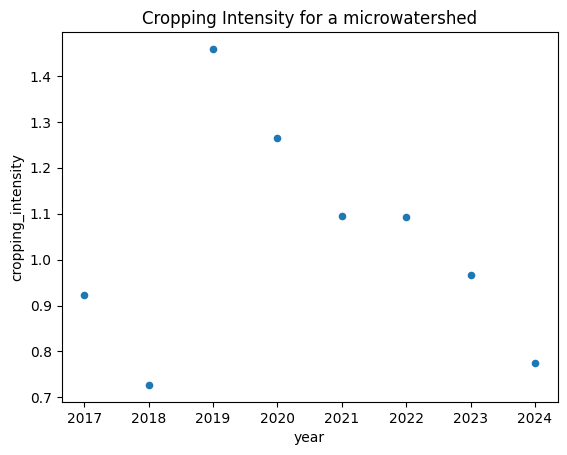

In [40]:
vector_data_mws_df.plot.scatter(x='year', y='cropping_intensity',title='Cropping Intensity for a microwatershed');

### Loading a selected raster item

In [31]:
raster_item = catalog.get_item(id='jharkhand_giridih_tisri_land_use_land_cover_raster_2024')
raster_item

<Item id=jharkhand_giridih_tisri_land_use_land_cover_raster_2024>

In [32]:
raster_item.assets

{'data': <Asset href=https://geoserver.core-stack.org:8443/geoserver/LULC_level_3/wcs?service=WCS&version=2.0.1&request=GetCoverage&CoverageId=LULC_level_3:LULC_24_25_giridih_tisri_level_3&format=geotiff>,
 'style': <Asset href=https://raw.githubusercontent.com/core-stack-org/QGIS-Styles/main/Land/LULC0_12class.qml>,
 'thumbnail': <Asset href=https://spatio-temporal-asset-catalog.s3.ap-south-1.amazonaws.com/STAC_output_merged_collection/jharkhand_giridih_tisri_land_use_land_cover_raster_2024.png>}

In [33]:
raster_asset_url=raster_item.assets['data'].href

In [34]:
raster_asset_url

'https://geoserver.core-stack.org:8443/geoserver/LULC_level_3/wcs?service=WCS&version=2.0.1&request=GetCoverage&CoverageId=LULC_level_3:LULC_24_25_giridih_tisri_level_3&format=geotiff'

In [47]:
response = requests.get(raster_item.assets['data'].href, verify=False)

/home/vishnu/miniconda3/envs/stac/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'geoserver.core-stack.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [48]:
with rasterio.open(BytesIO(response.content)) as src:
        
        bounds = src.bounds
        shape = src.shape
        

        data = src.read()
 
        data = src.read(1) 
        print(f"Shape of data: {data.shape}")
        print(f"Coordinate System: {src.crs}")
        print(f"Bounds: {src.bounds}")
        

Shape of data: (3900, 3549)
Coordinate System: EPSG:4326
Bounds: BoundingBox(left=85.8755275637466, bottom=24.45852007225062, right=86.19433965808062, top=24.808863033057236)


In [53]:
res = src.res  
    
gsd = res[0]
print(f"gsd: {gsd}")

gsd: 8.983152841195215e-05
